# First-Quadrant I-V Physical Modeling at Room Temperature


In [1]:
# Import the room-temperature data loader, fixed surface PINN, and physical channel-current model.
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from DeviceData import load_iv_characteristics
from SurfacePotential import load_surface_potential_pkl, surface_potential
from Channel_Current_Ich import effective_vds, effective_mobility, lateral_field, channel_integral_I_phi, channel_current_physical
from IVPhysicalModel import IVPhysicalParameters, save_iv_physical_pkl

## Room-temperature data and physical parameters


In [ ]:
# Load only the 25 C output and transfer datasets.
device = torch.device("cpu")
dtype = torch.float32
torch.manual_seed(42)
BASE_DIR = Path.cwd()
TEMPLATE_DIR = BASE_DIR / "Template"

dataset = load_iv_characteristics(TEMPLATE_DIR, transfer_vds=20.0)
print(dataset.groupby(["characteristic", "T_C"]).size())
print("Total I-V points =", len(dataset))

def to_tensor(name):
    return torch.tensor(dataset[name].to_numpy(np.float32), dtype=dtype, device=device).reshape(-1, 1)

Vgs_data = to_tensor("Vgs")
Vds_data = to_tensor("Vds")
T_K_data = to_tensor("T_K")
Ids_data = to_tensor("Ids")
output_mask = torch.tensor((dataset["characteristic"] == "output").to_numpy(), device=device)
transfer_mask = torch.tensor((dataset["characteristic"] == "transfer").to_numpy(), device=device)


characteristic  T_C 
output          25.0    157
transfer        25.0     27
dtype: int64
Total I-V points = 184


In [3]:
# Use the same room-temperature surface-potential constants as the phis PINN pretraining stage.
NA = 1.0e16
eps_sic = 9.26 * 8.854e-14
Cox = 7.0e-8
Vfbs0 = -1.0
Dit_mid = 2.0e11
Dit_edge = 2.0e13
sigma_it = 0.1
Eg = 3.26
Ec_minus_Ei = Eg / 2.0
Qox = 1.602e-7

surface_model, surface_checkpoint = load_surface_potential_pkl(BASE_DIR / "phis_PINN.pkl", device=device, dtype=dtype, freeze=True)

iv_parameters = IVPhysicalParameters(Lch_cm=1.0e-4).to(device=device, dtype=dtype)

print("Trainable I-V parameters:")
for name, parameter in iv_parameters.named_parameters():
    print(name, parameter.requires_grad)

Trainable I-V parameters:
log_K True
log_mu0 True
log_lambda0 True
log_vsat True
raw_delta True


## Room-temperature physical I-V parameter optimization


In [4]:
# Calculate Vdssat numerically from the stationary point of the intrinsic channel current.
def calculate_vdssat_psp(Vgs, T_K, values, vch_max=20.0, grid_points=160):
    original_shape = Vgs.shape

    with torch.no_grad():
        # Solve Vdssat only once for each unique gate voltage.
        Vgs_unique, inverse = torch.unique(Vgs.detach().reshape(-1), sorted=True, return_inverse=True)
        Vgs_unique = Vgs_unique.reshape(-1, 1)

        n_vgs = Vgs_unique.shape[0]

        # Create the trial channel-voltage axis.
        Vch_axis = torch.linspace(1.0e-3, vch_max, grid_points, dtype=Vgs.dtype, device=Vgs.device)

        # Create a two-dimensional Vgs-Vch evaluation grid.
        Vgs_grid = Vgs_unique.expand(-1, grid_points).reshape(-1, 1)
        Vch_grid = Vch_axis.reshape(1, -1).expand(n_vgs, -1).reshape(-1, 1)
        T_unique = torch.full_like(Vgs_unique, 298.15)
        T_grid = torch.full_like(Vch_grid, 298.15)

        # Calculate the source-end surface potential.
        phis_s0_unique = surface_potential(surface_model, Vgs_unique, torch.zeros_like(Vgs_unique), T=T_unique, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg)

        # Expand the source-end surface potential over the trial voltage axis.
        phis_s0_grid = phis_s0_unique.expand(-1, grid_points).reshape(-1, 1)

        # Calculate the drain-end surface potential for every trial channel voltage.
        phis_sL_grid = surface_potential(surface_model, Vgs_grid, Vch_grid, T=T_grid, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg)

        # Calculate the channel-current integral for every trial channel voltage.
        I_phi_grid = channel_integral_I_phi(Vgs_grid, Vch_grid, phis_s0_grid, phis_sL_grid, Vfbs0, Cox, Qox, Dit_mid, Dit_edge, sigma_it, Ec_minus_Ei, T_grid, NA, Eg, eps_sic)

        # Calculate the lateral electric field.
        Ey_grid = lateral_field(phis_s0_grid, phis_sL_grid, values["Lch_cm"])

        # Calculate the high-field effective mobility.
        mu_eff_grid = effective_mobility(values["mu_lf"], Ey_grid, values["vsat"])

        # Calculate the intrinsic channel current without channel-length modulation.
        Ich0_grid = values["K"] * mu_eff_grid * I_phi_grid
        Ich0_grid = Ich0_grid.reshape(n_vgs, grid_points)

        # Approximate dIch0/dVch using finite differences.
        dV = Vch_axis[1:] - Vch_axis[:-1]
        slope = (Ich0_grid[:, 1:] - Ich0_grid[:, :-1]) / dV.reshape(1, -1)

        # Associate each derivative with the midpoint of its voltage interval.
        Vmid = 0.5 * (Vch_axis[1:] + Vch_axis[:-1])

        # Detect the first positive-to-negative derivative crossing.
        crossing = (slope[:, :-1] > 0.0) & (slope[:, 1:] <= 0.0)
        has_crossing = crossing.any(dim=1)
        crossing_index = crossing.to(torch.int64).argmax(dim=1)

        row_index = torch.arange(n_vgs, device=Vgs.device)

        # Read the derivative values on both sides of the stationary point.
        slope_left = slope[row_index, crossing_index]
        slope_right = slope[row_index, crossing_index + 1]

        # Read the corresponding channel-voltage coordinates.
        voltage_left = Vmid[crossing_index]
        voltage_right = Vmid[crossing_index + 1]

        # Interpolate the zero-derivative location.
        denominator = slope_right - slope_left
        denominator = torch.where(torch.abs(denominator) > 1.0e-12, denominator, torch.full_like(denominator, 1.0e-12))
        Vdssat_crossing = voltage_left - slope_left * (voltage_right - voltage_left) / denominator

        # Use the discrete intrinsic-current maximum if no derivative crossing exists.
        peak_index = torch.argmax(Ich0_grid, dim=1)
        Vdssat_fallback = Vch_axis[peak_index]

        # Select the stationary solution when available and otherwise use the current maximum.
        Vdssat_unique = torch.where(has_crossing, Vdssat_crossing, Vdssat_fallback)

        # Apply only numerical safety limits.
        Vdssat_unique = torch.clamp(Vdssat_unique, min=1.0e-3, max=vch_max)

        # Map the unique Vgs solutions back to the original input positions.
        Vdssat = Vdssat_unique[inverse].reshape(original_shape)

    return Vdssat


# Evaluate the complete room-temperature surface-potential-based I-V model.
def evaluate_iv(Vgs, Vds, T_K):
    values = iv_parameters.values(Vgs, T_K)

    # Derive Vdssat from the intrinsic-current stationary condition.
    Vdssat = calculate_vdssat_psp(Vgs, T_K, values)

    # Convert the external drain voltage into the smooth effective drain voltage.
    Vdseff = effective_vds(Vds, Vdssat, values["delta"])

    # Calculate the source-end surface potential.
    phis_s0 = surface_potential(surface_model, Vgs, torch.zeros_like(Vgs), T=T_K, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg)

    # Calculate the drain-end surface potential using the effective drain voltage.
    phis_sL = surface_potential(surface_model, Vgs, Vdseff, T=T_K, NA=NA, eps_sic=eps_sic, Cox=Cox, Vfbs0=Vfbs0, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Eg=Eg)

    # Calculate the final channel current including high-field mobility and channel-length modulation.
    Ids, mu_eff, I_phi = channel_current_physical(Vgs, Vds, Vdseff, phis_s0, phis_sL, Vfbs0=Vfbs0, Cox=Cox, Qox=Qox, Dit_mid=Dit_mid, Dit_edge=Dit_edge, sigma_it=sigma_it, Ec_minus_Ei=Ec_minus_Ei, T=T_K, NA=NA, Eg=Eg, eps_sic=eps_sic, K_current_gain=values["K"], mu_lf_cm2_Vs=values["mu_lf"], lambda_clm=values["lambda_clm"], Lch_cm=values["Lch_cm"], vsat_cm_s=values["vsat"])

    return Ids, Vdseff, phis_s0, phis_sL, mu_eff, I_phi

In [6]:
# Optimize only the room-temperature physical I-V parameters while keeping phis_PINN.pkl fixed.
EPOCHS = 10000
LEARNING_RATE = 1.0e-4
CURRENT_SCALE = max(float(np.abs(dataset["Ids"]).max()), 1.0)

trainable_iv_parameters = [parameter for parameter in iv_parameters.parameters() if parameter.requires_grad]

optimizer = torch.optim.Adam(trainable_iv_parameters, lr=LEARNING_RATE)

loss_history = []
best_loss = float("inf")
best_iv_state = None

for epoch in range(EPOCHS):
    optimizer.zero_grad(set_to_none=True)

    Ids_pred, _, _, _, _, _ = evaluate_iv(Vgs_data, Vds_data, T_K_data)

    output_loss = torch.mean(((Ids_pred[output_mask] - Ids_data[output_mask]) / CURRENT_SCALE) ** 2)
    transfer_loss = torch.mean(((Ids_pred[transfer_mask] - Ids_data[transfer_mask]) / CURRENT_SCALE) ** 2)

    loss = 0.5 * output_loss + 0.5 * transfer_loss

    if not torch.isfinite(loss):
        raise RuntimeError(f"Non-finite loss at epoch {epoch}")

    loss.backward()

    torch.nn.utils.clip_grad_norm_(trainable_iv_parameters, max_norm=10.0)

    optimizer.step()

    value = loss.item()
    loss_history.append(value)

    if value < best_loss:
        best_loss = value
        best_iv_state = {key: parameter.detach().cpu().clone() for key, parameter in iv_parameters.state_dict().items()}

    if epoch % 200 == 0 or epoch == EPOCHS - 1:
        rmse = torch.sqrt(torch.mean((Ids_pred.detach() - Ids_data) ** 2)).item()
        print(f"Epoch {epoch:4d} | loss = {value:.6e} | RMSE = {rmse:.4f} A")

iv_parameters.load_state_dict(best_iv_state, strict=True)

print("Best loss =", best_loss)
print(pd.DataFrame([iv_parameters.report()]))

Epoch    0 | loss = 7.707365e-02 | RMSE = 20.9772 A
Epoch  200 | loss = 7.457256e-02 | RMSE = 20.5037 A
Epoch  400 | loss = 7.204951e-02 | RMSE = 20.0159 A
Epoch  600 | loss = 6.951264e-02 | RMSE = 19.5145 A
Epoch  800 | loss = 6.697465e-02 | RMSE = 19.0011 A
Epoch 1000 | loss = 6.444791e-02 | RMSE = 18.4776 A
Epoch 1200 | loss = 6.195464e-02 | RMSE = 17.9482 A
Epoch 1400 | loss = 5.950876e-02 | RMSE = 17.4156 A
Epoch 1600 | loss = 5.712935e-02 | RMSE = 16.8840 A
Epoch 1800 | loss = 5.483808e-02 | RMSE = 16.3591 A
Epoch 2000 | loss = 5.265083e-02 | RMSE = 15.8454 A
Epoch 2200 | loss = 5.058754e-02 | RMSE = 15.3493 A
Epoch 2400 | loss = 4.866660e-02 | RMSE = 14.8774 A
Epoch 2600 | loss = 4.690335e-02 | RMSE = 14.4362 A
Epoch 2800 | loss = 4.531239e-02 | RMSE = 14.0325 A
Epoch 3000 | loss = 4.390372e-02 | RMSE = 13.6720 A
Epoch 3200 | loss = 4.268330e-02 | RMSE = 13.3597 A
Epoch 3400 | loss = 4.165205e-02 | RMSE = 13.0985 A
Epoch 3600 | loss = 4.080467e-02 | RMSE = 12.8891 A
Epoch 3800 |

## Save the physical I-V parameters and model bundle


In [8]:
# Save the fitted room-temperature physical parameters without changing phis_PINN.pkl.
save_iv_physical_pkl(
    BASE_DIR / "Ich_physical_25C.pkl",
    iv_parameters,
    training_metadata={
        "temperature_C": 25.0,
        "best_loss": best_loss,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "surface_PINN_file": "phis_PINN.pkl",
        "surface_PINN_frozen": True,
    },
)

bundle = {
    "format_version": 2,
    "model_name": "SiC_MOSFET_First_Quadrant_IV_25C",
    "temperature_C": 25.0,
    "surface_potential_PINN": torch.load(BASE_DIR / "phis_PINN.pkl", map_location="cpu", weights_only=False),
    "Ich_physical": torch.load(BASE_DIR / "Ich_physical_25C.pkl", map_location="cpu", weights_only=False),
}
torch.save(bundle, BASE_DIR / "Ich_Model_25C.pkl")
print("Saved Ich_physical_25C.pkl and Ich_Model_25C.pkl")


Saved Ich_physical_25C.pkl and Ich_Model_25C.pkl


## Accuracy and room-temperature curve comparison


In [9]:
# Report the room-temperature fit error for the output and transfer datasets.
surface_model.eval()
iv_parameters.eval()
with torch.no_grad():
    Ids_fit, _, _, _, _, _ = evaluate_iv(Vgs_data, Vds_data, T_K_data)
error = Ids_fit - Ids_data
overall_rmse = torch.sqrt(torch.mean(error**2)).item()
output_rmse = torch.sqrt(torch.mean(error[output_mask]**2)).item()
transfer_rmse = torch.sqrt(torch.mean(error[transfer_mask]**2)).item()
print(f"Overall RMSE = {overall_rmse:.4f} A")
print(f"Output RMSE = {output_rmse:.4f} A")
print(f"Transfer RMSE = {transfer_rmse:.4f} A")


Overall RMSE = 11.9389 A
Output RMSE = 11.3519 A
Transfer RMSE = 14.9008 A


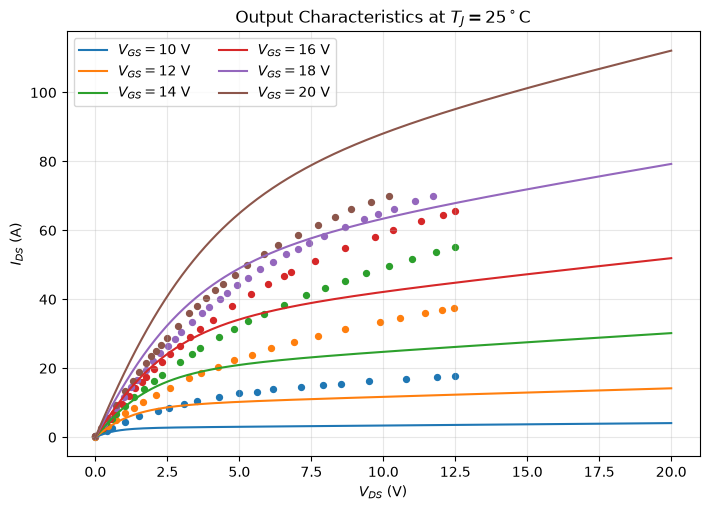

In [10]:
# Plot the measured and modeled room-temperature output characteristics.
def predict_curve(vgs_value, vds_max=20.0, points=300):
    Vds = torch.linspace(0.0, vds_max, points, dtype=dtype, device=device).reshape(-1, 1)
    Vgs = torch.full_like(Vds, float(vgs_value))
    T_K = torch.full_like(Vds, 298.15)
    with torch.no_grad():
        Ids, _, _, _, _, _ = evaluate_iv(Vgs, Vds, T_K)
    return Vds.cpu().numpy().reshape(-1), Ids.cpu().numpy().reshape(-1)

plt.figure(figsize=(7.2, 5.2))
part_t = dataset[dataset["characteristic"] == "output"]
for vgs_value in sorted(part_t["Vgs"].unique()):
    measured = part_t[np.isclose(part_t["Vgs"], vgs_value)]
    plt.scatter(measured["Vds"], measured["Ids"], s=18)
    x, y = predict_curve(vgs_value, vds_max=max(20.0, measured["Vds"].max()))
    plt.plot(x, y, label=rf"$V_{{GS}}={vgs_value:g}$ V")
plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ (A)")
plt.title(r"Output Characteristics at $T_J=25^\circ$C")
plt.grid(True, alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


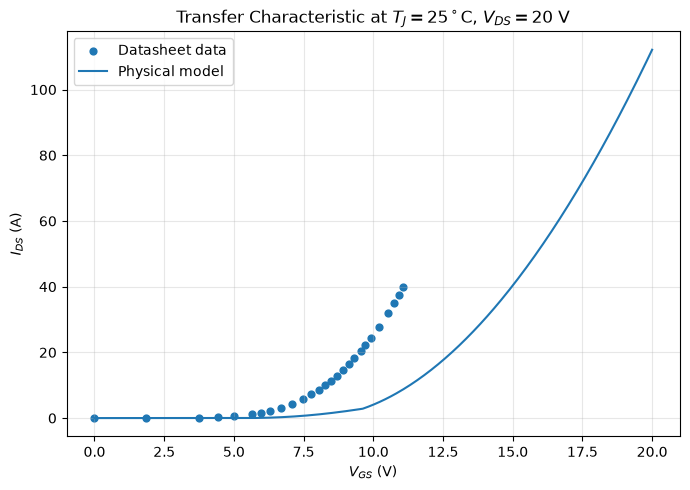

In [11]:
# Plot the measured and modeled room-temperature transfer characteristic.
measured = dataset[dataset["characteristic"] == "transfer"]
Vgs = torch.linspace(0.0, 20.0, 400, dtype=dtype, device=device).reshape(-1, 1)
Vds = torch.full_like(Vgs, 20.0)
T_K = torch.full_like(Vgs, 298.15)
with torch.no_grad():
    Ids, _, _, _, _, _ = evaluate_iv(Vgs, Vds, T_K)
plt.figure(figsize=(7.0, 5.0))
plt.scatter(measured["Vgs"], measured["Ids"], s=24, label="Datasheet data")
plt.plot(Vgs.cpu(), Ids.cpu(), label="Physical model")
plt.xlabel(r"$V_{GS}$ (V)")
plt.ylabel(r"$I_{DS}$ (A)")
plt.title(r"Transfer Characteristic at $T_J=25^\circ$C, $V_{DS}=20$ V")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


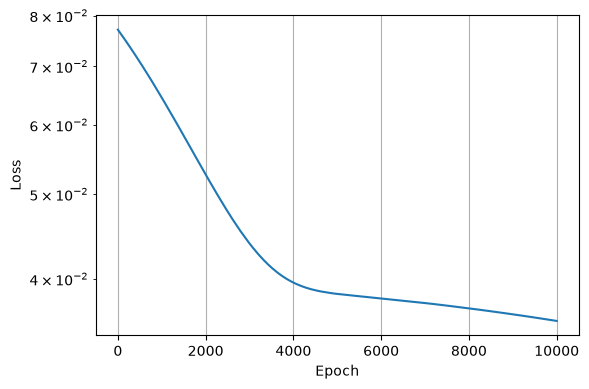

In [12]:
# Plot the room-temperature I-V training objective.
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()
